In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import lab_report

In [2]:
def gaussian(x_values, amplitude, mean, std_dev):
    return amplitude * np.exp(-((x_values - mean) ** 2) / (2 * std_dev ** 2))
def exp_decay(x_values, amplitude, tau):
    return amplitude * np.exp(-(x_values)/(tau))
pathname = '/workspaces/CP1-24-final/ojha-aditya/data'
series_047 = lab_report.filename_lister(pathname, '047', 'csv')
series_097 = lab_report.filename_lister(pathname, '097', 'csv')

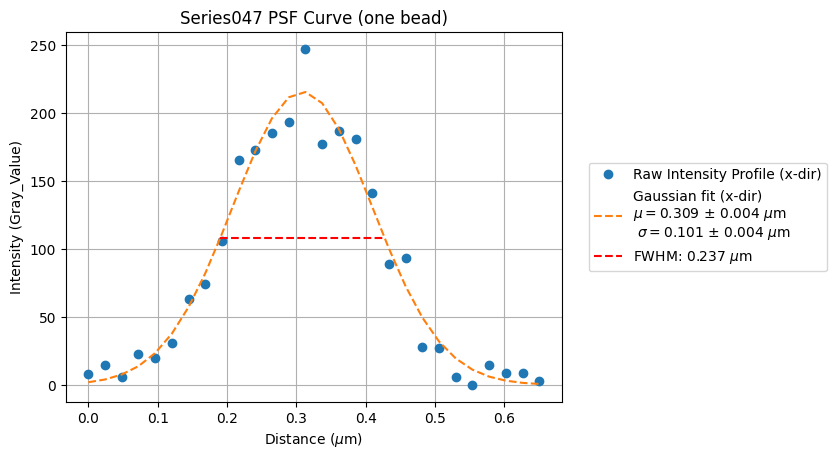

In [3]:
time, intensity = lab_report.get_coordinates(pathname+'/Series047-4x.csv')
initial_guess = [np.max(intensity), np.mean(time), np.std(time)]
fit_params, fit_cov = sp.optimize.curve_fit(gaussian, time, intensity, initial_guess)
fit_err = np.sqrt(np.diag(fit_cov))
fit_data = gaussian(time, *fit_params)

plt.plot(time, intensity, 'o', label='Raw Intensity Profile (x-dir)') 
label_fit='Gaussian fit (x-dir) \n'+'$\\mu = $'+str(round(fit_params[1], 3))+' $\\pm$ '+str(round(fit_err[1], 3))+' $\\mu$m\n '+'$\\sigma = $'+str(round(fit_params[2], 3))+' $\\pm$ '+str(round(fit_err[2], 3))+' $\\mu$m'
plt.plot(time, fit_data, '--', label=label_fit)
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Intensity (Gray_Value)')
plt.title('Series047 PSF Curve (one bead)')
x1 = fit_params[1] - (np.sqrt(2*np.log(2))*fit_params[2])
x2 = fit_params[1] + (np.sqrt(2*np.log(2))*fit_params[2])
y1 = gaussian(x1, *fit_params)
y2 = gaussian(x2, *fit_params)
plt.hlines(y=y1, xmin=x1, xmax=x2, colors='red', linestyles='--', label='FWHM: '+str(round(2*np.sqrt(2*np.log(2))*fit_params[2], 3))+' $\mu$m')
plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left")
plt.grid()

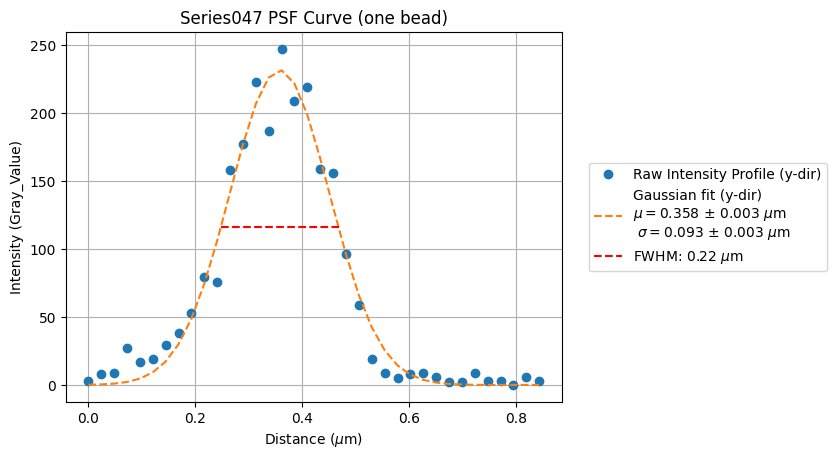

In [4]:
time, intensity = lab_report.get_coordinates(pathname+'/Series047-4y.csv')
initial_guess = [np.max(intensity), np.mean(time), np.std(time)]
fit_params, fit_cov = sp.optimize.curve_fit(gaussian, time, intensity, initial_guess)
fit_err = np.sqrt(np.diag(fit_cov))
fit_data = gaussian(time, *fit_params)

plt.plot(time, intensity, 'o', label='Raw Intensity Profile (y-dir)') 
label_fit='Gaussian fit (y-dir) \n'+'$\\mu = $'+str(round(fit_params[1], 3))+' $\\pm$ '+str(round(fit_err[1], 3))+' $\\mu$m\n '+'$\\sigma = $'+str(round(fit_params[2], 3))+' $\\pm$ '+str(round(fit_err[2], 3))+' $\\mu$m'
plt.plot(time, fit_data, '--', label=label_fit)
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Intensity (Gray_Value)')
plt.title('Series047 PSF Curve (one bead)')
x1 = fit_params[1] - (np.sqrt(2*np.log(2))*fit_params[2])
x2 = fit_params[1] + (np.sqrt(2*np.log(2))*fit_params[2])
y1 = gaussian(x1, *fit_params)
y2 = gaussian(x2, *fit_params)
plt.hlines(y=y1, xmin=x1, xmax=x2, colors='red', linestyles='--', label='FWHM: '+str(round(2*np.sqrt(2*np.log(2))*fit_params[2], 3))+' $\mu$m')
plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left")
plt.grid()

In [5]:
amp = []
mu = []
sigma = []
err_amp = []
err_mu = []
err_sigma = []

for filename in series_047:
    time, intensity = lab_report.get_coordinates(pathname+'/'+filename)
    initial_guess = [np.max(intensity), np.mean(time), np.std(time)]
    fit_params, fit_cov = sp.optimize.curve_fit(gaussian, time, intensity, initial_guess)
    fit_err = np.sqrt(np.diag(fit_cov))
    #fit_data = gaussian(time, *fit_params)

    #plt.plot(time, intensity, '.', label='Raw Intensity Profile') 
    #label_fit='Gaussian fit \n'+'$\\mu = $'+str(round(fit_params[1], 2))+' $\\mu$m\n '+'$\\sigma = $'+str(round(fit_params[2], 2))+' $\\mu$m'
    #plt.plot(time, fit_data, '--', label=label_fit)
    #plt.xlabel('Distance ($\\mu$m)')
    #plt.ylabel('Intensity (Gray_Value)')
    #plt.title('Series047 PSF Curve')
    #plt.grid()
    #plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left")
    
    amp.append(fit_params[0])
    mu.append(fit_params[1])
    sigma.append(fit_params[2])
    err_amp.append(fit_err[0])
    err_mu.append(fit_err[1])
    err_sigma.append(fit_err[2])

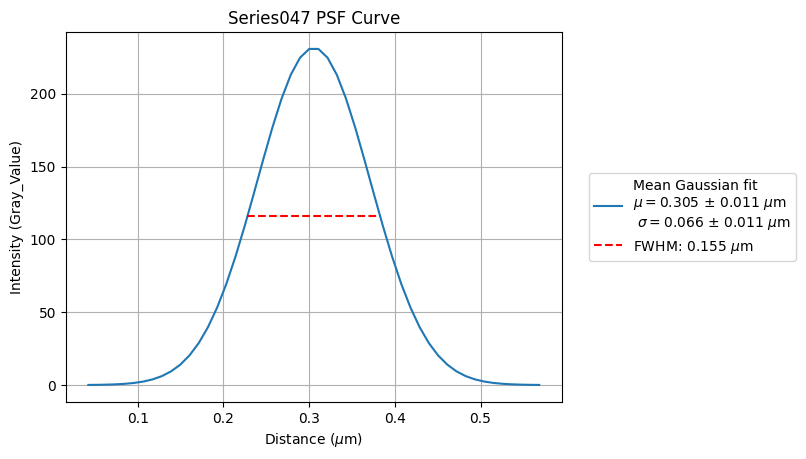

In [6]:
mean_amp_047 = np.mean(amp)
mean_mu_047 = np.mean(mu)
mean_sigma_047 = np.mean(sigma)
err_amp_047 = np.linalg.norm(err_amp)
err_mu_047 = np.linalg.norm(err_mu)
err_sigma_047 = np.linalg.norm(err_sigma)

x = np.linspace(mean_mu_047 - 4 * mean_sigma_047, mean_mu_047 + 4 * mean_sigma_047)
label_fit='Mean Gaussian fit \n'+'$\\mu = $'+str(round(mean_mu_047, 3))+' $\\pm$ '+str(round(err_mu_047, 3))+' $\\mu$m\n '+'$\\sigma = $'+str(round(mean_sigma_047, 3))+' $\\pm$ '+str(round(err_sigma_047, 3))+' $\\mu$m'
plt.plot(x, gaussian(x, mean_amp_047, mean_mu_047, mean_sigma_047), label = label_fit)
x1 = mean_mu_047 - (np.sqrt(2*np.log(2))*mean_sigma_047)
x2 = mean_mu_047 + (np.sqrt(2*np.log(2))*mean_sigma_047)
y1 = gaussian(x1, mean_amp_047, mean_mu_047, mean_sigma_047)
y2 = gaussian(x2, mean_amp_047, mean_mu_047, mean_sigma_047)
plt.hlines(y=y1, xmin=x1, xmax=x2, colors='red', linestyles='--', label='FWHM: '+str(round(2*np.sqrt(2*np.log(2))*mean_sigma_047, 3))+' $\mu$m')
plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left")
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Intensity (Gray_Value)')
plt.title('Series047 PSF Curve')
plt.grid()


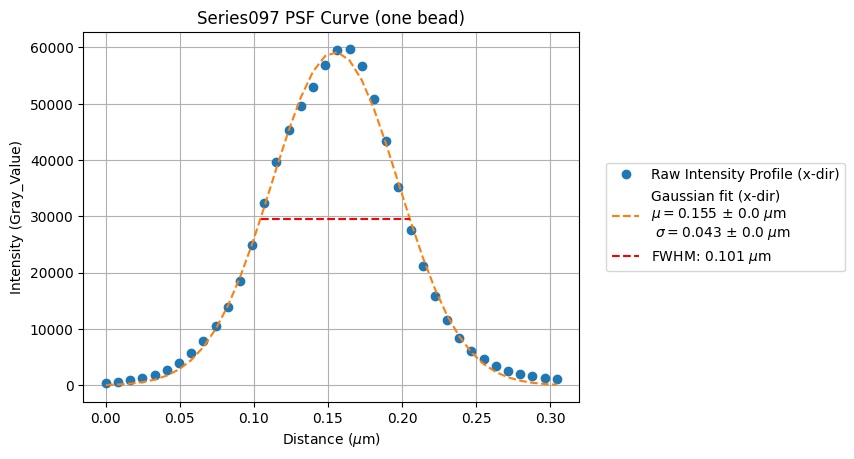

In [7]:
time, intensity = lab_report.get_coordinates(pathname+'/Series097-5x.csv')
initial_guess = [np.max(intensity), np.mean(time), np.std(time)]
fit_params, fit_cov = sp.optimize.curve_fit(gaussian, time, intensity, initial_guess)
fit_err = np.sqrt(np.diag(fit_cov))
fit_data = gaussian(time, *fit_params)

plt.plot(time, intensity, 'o', label='Raw Intensity Profile (x-dir)') 
label_fit='Gaussian fit (x-dir) \n'+'$\\mu = $'+str(round(fit_params[1], 3))+' $\\pm$ '+str(round(fit_err[1], 3))+' $\\mu$m\n '+'$\\sigma = $'+str(round(fit_params[2], 3))+' $\\pm$ '+str(round(fit_err[2], 3))+' $\\mu$m'
plt.plot(time, fit_data, '--', label=label_fit)
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Intensity (Gray_Value)')
x1 = fit_params[1] - (np.sqrt(2*np.log(2))*fit_params[2])
x2 = fit_params[1] + (np.sqrt(2*np.log(2))*fit_params[2])
y1 = gaussian(x1, *fit_params)
y2 = gaussian(x2, *fit_params)
plt.hlines(y=y1, xmin=x1, xmax=x2, colors='red', linestyles='--', label='FWHM: '+str(round(2*np.sqrt(2*np.log(2))*fit_params[2], 3))+' $\mu$m')
plt.title('Series097 PSF Curve (one bead)')
plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left")
plt.grid()

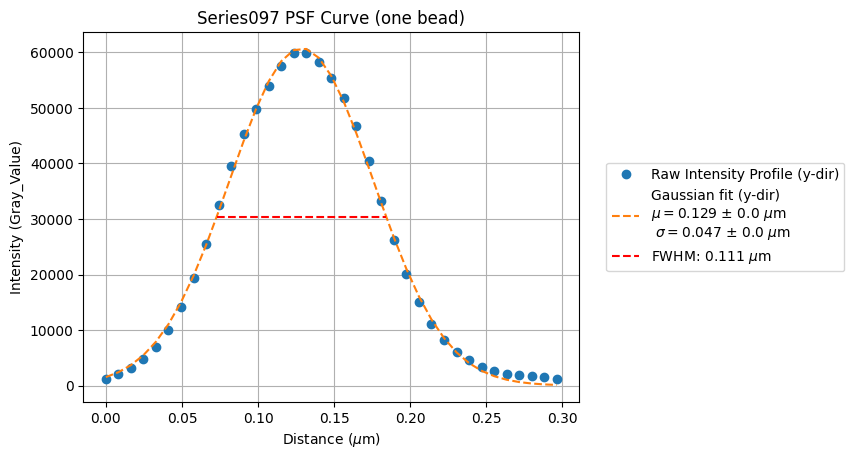

In [8]:
time, intensity = lab_report.get_coordinates(pathname+'/Series097-5y.csv')
initial_guess = [np.max(intensity), np.mean(time), np.std(time)]
fit_params, fit_cov = sp.optimize.curve_fit(gaussian, time, intensity, initial_guess)
fit_err = np.sqrt(np.diag(fit_cov))
fit_data = gaussian(time, *fit_params)

plt.plot(time, intensity, 'o', label='Raw Intensity Profile (y-dir)') 
label_fit='Gaussian fit (y-dir) \n'+'$\\mu = $'+str(round(fit_params[1], 3))+' $\\pm$ '+str(round(fit_err[1], 3))+' $\\mu$m\n '+'$\\sigma = $'+str(round(fit_params[2], 3))+' $\\pm$ '+str(round(fit_err[2], 3))+' $\\mu$m'
plt.plot(time, fit_data, '--', label=label_fit)
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Intensity (Gray_Value)')
x1 = fit_params[1] - (np.sqrt(2*np.log(2))*fit_params[2])
x2 = fit_params[1] + (np.sqrt(2*np.log(2))*fit_params[2])
y1 = gaussian(x1, *fit_params)
y2 = gaussian(x2, *fit_params)
plt.hlines(y=y1, xmin=x1, xmax=x2, colors='red', linestyles='--', label='FWHM: '+str(round(2*np.sqrt(2*np.log(2))*fit_params[2], 3))+' $\mu$m')
plt.title('Series097 PSF Curve (one bead)')
plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left")
plt.grid()

In [9]:
amp = []
mu = []
sigma = []
err_amp = []
err_mu = []
err_sigma = []

for filename in series_097:
    time, intensity = lab_report.get_coordinates(pathname+'/'+filename)
    initial_guess = [np.max(intensity), np.mean(time), np.std(time)]
    fit_params, fit_cov = sp.optimize.curve_fit(gaussian, time, intensity, initial_guess)

    #fit_data = gaussian(time, *fit_params)

    #plt.plot(time, intensity, '.', label='Raw Intensity Profile') 
    #label_fit='Gaussian fit \n'+'$\\mu = $'+str(round(fit_params[1], 2))+' $\\mu$m\n '+'$\\sigma = $'+str(round(fit_params[2], 2))+' $\\mu$m'
    #plt.plot(time, fit_data, '--', label=label_fit)
    #plt.xlabel('Distance ($\\mu$m)')
    #plt.ylabel('Intensity (Gray_Value)')
    #plt.title('Series047 PSF Curve')
    #plt.grid()
    #plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left")
    
    amp.append(fit_params[0])
    mu.append(fit_params[1])
    sigma.append(fit_params[2])
    err_amp.append(fit_err[0])
    err_mu.append(fit_err[1])
    err_sigma.append(fit_err[2])

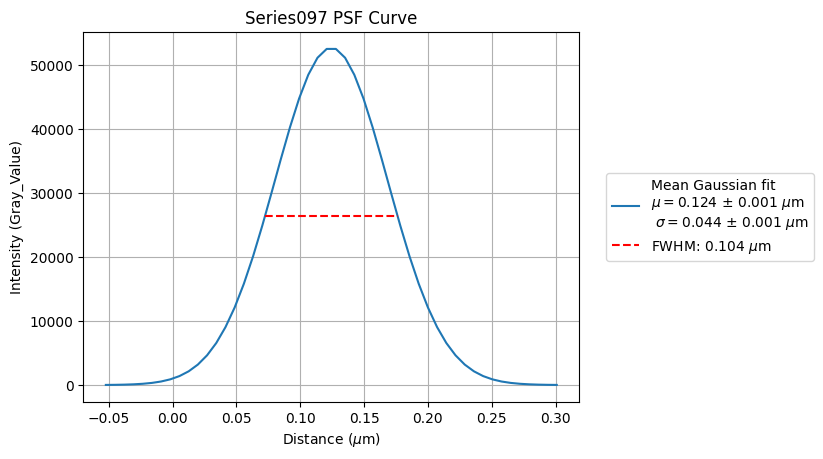

In [10]:
mean_amp_097 = np.mean(amp)
mean_mu_097 = np.mean(mu)
mean_sigma_097 = np.mean(sigma)
err_amp_097 = np.linalg.norm(err_amp)
err_mu_097 = np.linalg.norm(err_mu)
err_sigma_097 = np.linalg.norm(err_sigma)

x = np.linspace(mean_mu_097 - 4 * mean_sigma_097, mean_mu_097 + 4 * mean_sigma_097)
label_fit='Mean Gaussian fit \n'+'$\\mu = $'+str(round(mean_mu_097, 3))+' $\\pm$ '+str(round(err_mu_097, 3))+' $\\mu$m\n '+'$\\sigma = $'+str(round(mean_sigma_097, 3))+' $\\pm$ '+str(round(err_sigma_097, 3))+' $\\mu$m'
plt.plot(x, gaussian(x, mean_amp_097, mean_mu_097, mean_sigma_097), label = label_fit)
x1 = mean_mu_097 - (np.sqrt(2*np.log(2))*mean_sigma_097)
x2 = mean_mu_097 + (np.sqrt(2*np.log(2))*mean_sigma_097)
y1 = gaussian(x1, mean_amp_097, mean_mu_097, mean_sigma_097)
y2 = gaussian(x2, mean_amp_097, mean_mu_097, mean_sigma_097)
plt.hlines(y=y1, xmin=x1, xmax=x2, colors='red', linestyles='--', label='FWHM: '+str(round(2*np.sqrt(2*np.log(2))*mean_sigma_097, 3))+' $\mu$m')
plt.legend(bbox_to_anchor=(1.04, 0.5), loc="center left")
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Intensity (Gray_Value)')
plt.title('Series097 PSF Curve')
plt.grid()

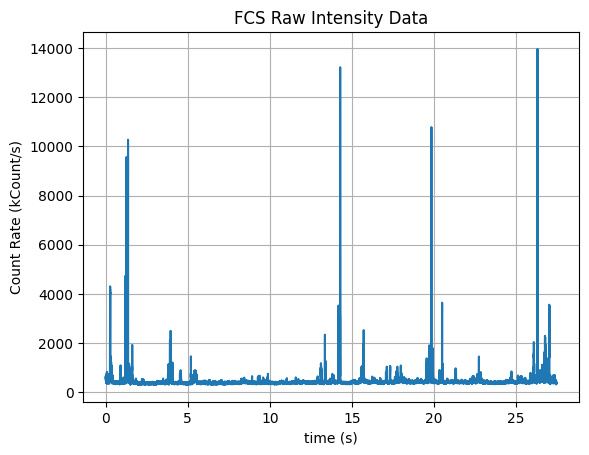

In [11]:
time, count_rate = lab_report.get_coordinates('/workspaces/CP1-24-final/ojha-aditya/data/FCS_hundert.csv', 'Time_[s]', 'Count_Rate_Channel_1_[kCounts/s]')
plt.plot(time, count_rate)
plt.xlabel('time (s)')
plt.ylabel('Count Rate (kCount/s)')
plt.title('FCS Raw Intensity Data')
plt.grid()

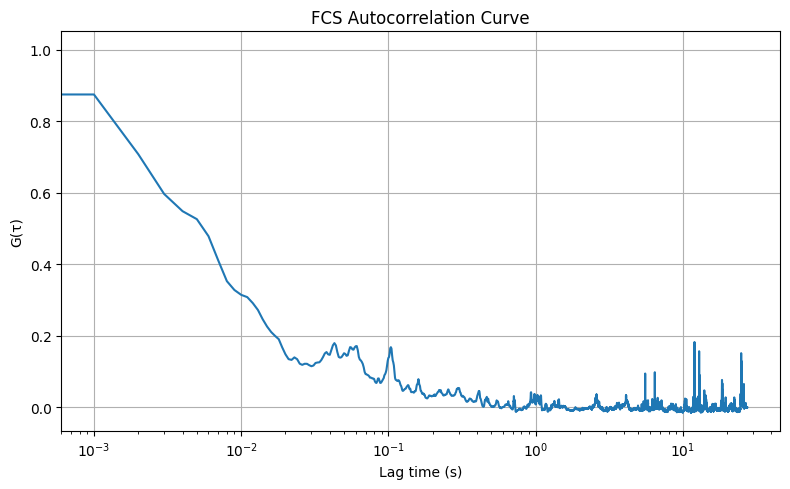

In [12]:
def load_fcs_data(filename):
    """
    Load FCS data from a CSV file with a header row.
    Assumes two columns: time (s) and intensity (kcps).
    """
    data = np.genfromtxt(filename, delimiter=',', skip_header=1)
    time = data[:, 0]
    intensity = data[:, 1]
    return time, intensity

def autocorrelation(intensity):
    """
    Compute the autocorrelation of the intensity signal.
    Normalized so that G(0) = 1.
    """
    n = len(intensity)
    intensity -= np.mean(intensity)
    result = np.correlate(intensity, intensity, mode='full')
    result = result[result.size // 2:]
    result /= result[0]  # Normalize
    return result

def plot_autocorrelation(time, ac):
    """
    Plot the autocorrelation curve vs lag time.
    """
    dt = time[1] - time[0]  # assuming uniform time steps
    lag_times = np.arange(len(ac)) * dt
    plt.figure(figsize=(8, 5))
    plt.semilogx(lag_times, ac)
    plt.xlabel("Lag time (s)")
    plt.ylabel("G(τ)")
    plt.title("FCS Autocorrelation Curve")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

time, intensity = load_fcs_data('/workspaces/CP1-24-final/ojha-aditya/data/FCS_hundert.csv')
ac = autocorrelation(intensity)
plot_autocorrelation(time, ac)

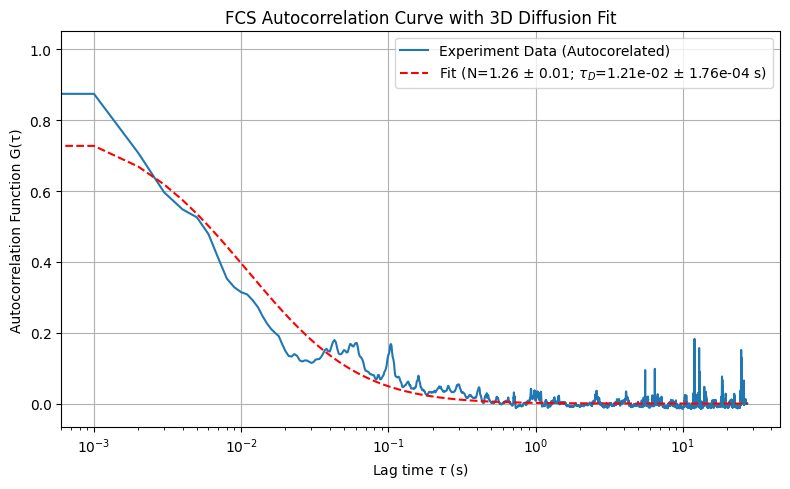

In [13]:
def g3d_model(tau, N, tau_D):
    """
    3D diffusion model for FCS autocorrelation.
    """
    return (1.0 / N) * (1.0 / (1.0 + tau / tau_D)) * (1.0 / np.sqrt(1.0 + tau / (4 * tau_D)))

def fit_autocorrelation(time, ac, fit_range=None, initial_guess=(1, 1e-4)):
    """
    Fit the autocorrelation data using the 3D diffusion model.
    fit_range: tuple (start_time, end_time) for fitting
    """
    dt = time[1] - time[0]
    lag_times = np.arange(len(ac)) * dt

    if fit_range:
        mask = (lag_times >= fit_range[0]) & (lag_times <= fit_range[1])
        lag_times_fit = lag_times[mask]
        ac_fit = ac[mask]
    else:
        lag_times_fit = lag_times
        ac_fit = ac

    popt, pcov = sp.optimize.curve_fit(g3d_model, lag_times_fit, ac_fit, p0=initial_guess, maxfev=10000)
    return popt, pcov, lag_times_fit, ac_fit

fit_params, fit_cov, lag_fit, ac_fit = fit_autocorrelation(time, ac, fit_range=(0, 100), initial_guess=(1, 1e-4))
fit_err = np.sqrt(np.diag(fit_cov))
N, tau_D = fit_params
err_N, err_tau_D = fit_err
# Plot the result
plt.figure(figsize=(8, 5))
dt = time[1] - time[0]
lag_times = np.arange(len(ac)) * dt
plt.semilogx(lag_times, ac, label='Experiment Data (Autocorelated)')
plt.semilogx(lag_fit, g3d_model(lag_fit, *fit_params), label=f'Fit (N={N:.2f} $\\pm$ {err_N:.2f}; $\\tau_D$={tau_D:.2e} $\\pm$ {err_tau_D:.2e} s)', linestyle='--', color = 'red')
plt.xlabel("Lag time $\\tau$ (s)")
plt.ylabel("Autocorrelation Function G(τ)")
plt.title("FCS Autocorrelation Curve with 3D Diffusion Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

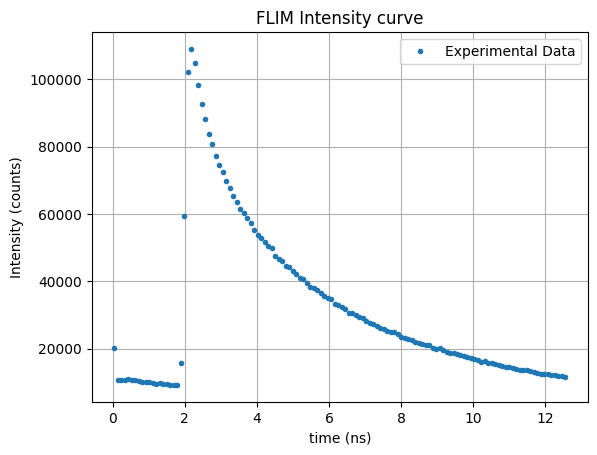

In [14]:
time, intensity = lab_report.get_coordinates('/workspaces/CP1-24-final/ojha-aditya/data/FLIM_Data_1.csv', 'Time_[ns]', 'Lifetime_Decay_HyD_4_[Counts]')
plt.plot(time, intensity, '.', label='Experimental Data') 
plt.xlabel('time (ns)')
plt.ylabel('Intensity (counts)')
plt.title('FLIM Intensity curve')
plt.legend()
plt.grid()

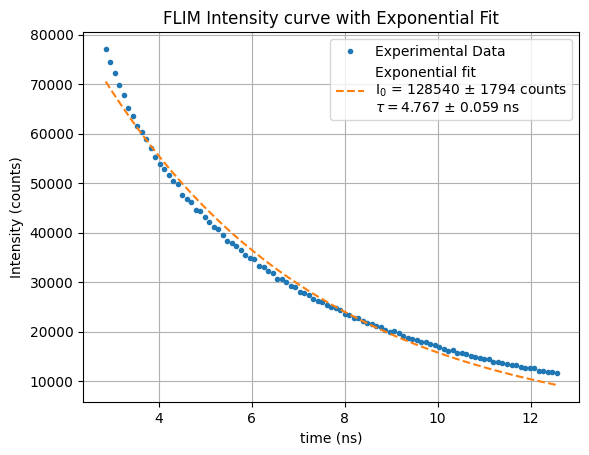

In [15]:
time, intensity = lab_report.get_coordinates('/workspaces/CP1-24-final/ojha-aditya/data/FLIM_Data_1.csv', 'Time_[ns]', 'Lifetime_Decay_HyD_4_[Counts]')
trim_time = time[29:]
trim_intensity = intensity[29:]
initial_guess = [np.max(trim_intensity), 4]
fit_params, fit_cov = sp.optimize.curve_fit(exp_decay, trim_time, trim_intensity, initial_guess)
fit_err = np.sqrt(np.diag(fit_cov))
fit_data = exp_decay(trim_time, *fit_params)

plt.plot(trim_time, trim_intensity, '.', label='Experimental Data') 
label_fit='Exponential fit \n'+'I$_0$ = '+str(round(fit_params[0]))+' $\\pm$ '+str(round(fit_err[0]))+' counts\n'+'$\\tau = $'+str(round(fit_params[1], 3))+' $\\pm$ '+str(round(fit_err[1], 3))+' ns'
plt.plot(trim_time, fit_data, '--', label=label_fit)
plt.xlabel('time (ns)')
plt.ylabel('Intensity (counts)')
plt.title('FLIM Intensity curve with Exponential Fit')
plt.legend()
plt.grid()

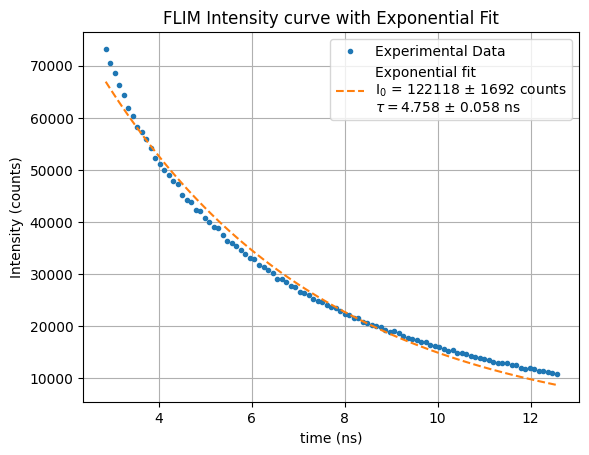

In [16]:
time, intensity = lab_report.get_coordinates('/workspaces/CP1-24-final/ojha-aditya/data/FLIM_Data_2.csv', 'Time_[ns]', 'Lifetime_Decay_HyD_4_[Counts]')
trim_time = time[29:]
trim_intensity = intensity[29:]
initial_guess = [np.max(trim_intensity), 4]
fit_params, fit_cov = sp.optimize.curve_fit(exp_decay, trim_time, trim_intensity, initial_guess)
fit_err = np.sqrt(np.diag(fit_cov))
fit_data = exp_decay(trim_time, *fit_params)

plt.plot(trim_time, trim_intensity, '.', label='Experimental Data') 
label_fit='Exponential fit \n'+'I$_0$ = '+str(round(fit_params[0]))+' $\\pm$ '+str(round(fit_err[0]))+' counts\n'+'$\\tau = $'+str(round(fit_params[1], 3))+' $\\pm$ '+str(round(fit_err[1], 3))+' ns'
plt.plot(trim_time, fit_data, '--', label=label_fit)
plt.xlabel('time (ns)')
plt.ylabel('Intensity (counts)')
plt.title('FLIM Intensity curve with Exponential Fit')
plt.legend()
plt.grid()